# Rain gauge (WAD)

Compared to other precipitation measurements, the data from the rain gauge shows significant discrepancies.

After initial investigations we estimate the bucket was reliable for about 3 months after its installation, after which the data became not suitable for scientific use, up until it was removed on 2025-09-25. It was reinstalled 2026-01-29 and is currently in operation. The data taken since then should be reevaluated for scientific usability.

When investigating the bucket’s data, please also note that on September 1, 2025 at 16:23, $100 \,\mathrm{ml}$
 of water was poured into the bucket as a test for instrument functionality.

## Rain Gauge (WAD) vs WXT and Disdrometers

In [42]:
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

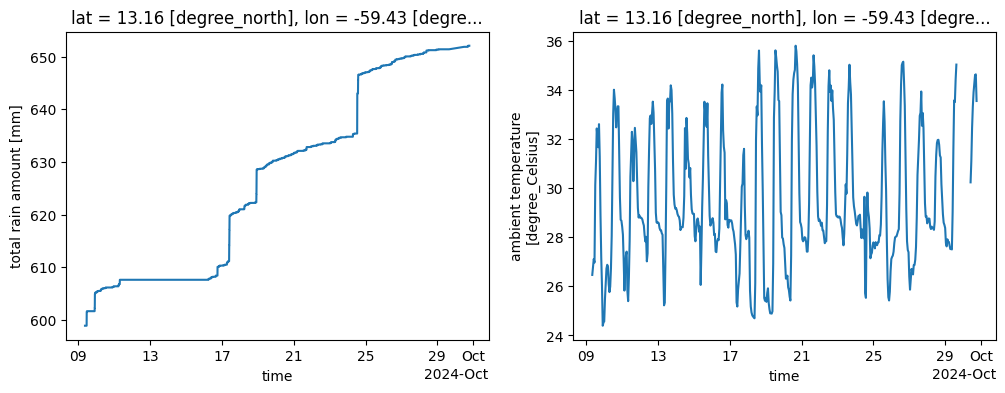

In [1]:
import intake
import matplotlib.pylab as plt

cat = intake.open_catalog("https://tcodata.mpimet.mpg.de/catalog.yaml")
ds_bucket = cat.BCO.bucket_WAD_c1_v1.to_dask()

# period of ORCESTRA
orcestra = slice("2024-09-09", "2024-09-30")

subset = ds_bucket.sel(time=orcestra)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
subset.R.plot(ax=ax1)
subset.T.compute().resample(time="1h").mean().plot(ax=ax2)

In [5]:
ds1 = cat.BCO.disdrometer_PARSIVEL451995_c1.to_dask()
ds2 = cat.BCO.disdrometer_PARSIVEL451996_c1_v2.to_dask()
ds3 = cat.BCO.disdrometer_PARSIVEL451997_c1_v2.to_dask()
wxt = cat.BCO.surfacemet_wxt_v1.to_dask()
wad = cat.BCO.bucket_WAD_c1_v1.to_dask()

In [6]:
wad

<xarray.Dataset> Size: 162MB
Dimensions:  (time: 7706566)
Coordinates:
    lat      float64 8B ...
    lon      float64 8B ...
  * time     (time) datetime64[ns] 62MB 2023-05-09T19:22:47 ... 2026-04-13T23...
Data variables:
    R        (time) float32 31MB dask.array<chunksize=(262144,), meta=np.ndarray>
    RIH      (time) float32 31MB dask.array<chunksize=(262144,), meta=np.ndarray>
    SYS      (time) int8 8MB dask.array<chunksize=(262144,), meta=np.ndarray>
    T        (time) float32 31MB dask.array<chunksize=(262144,), meta=np.ndarray>
    alt      float64 8B ...
Attributes:
    Conventions:           CF-1.12
    _logical_cutoff_date:  2026-04-14T00:00:00Z
    bcoproc_version:       0.0.0.post1287.dev0+e1e8fbd
    featureType:           timeSeries
    institution:           Max Planck Institute for Meteorology, Hamburg
    license:               CC0-1.0
    location:              The Barbados Cloud Observatory (BCO), Deebles Poin...
    platform:              BCO
    source:                OTT WAD 200
    summary:               This dataset contains precipitation measurements f...
    title:                 Raingauge measurements from BCO (Level 1)
    tool_versions:         {"Python": "3.11.2 (main, Apr 28 2025, 14:11:48) [...

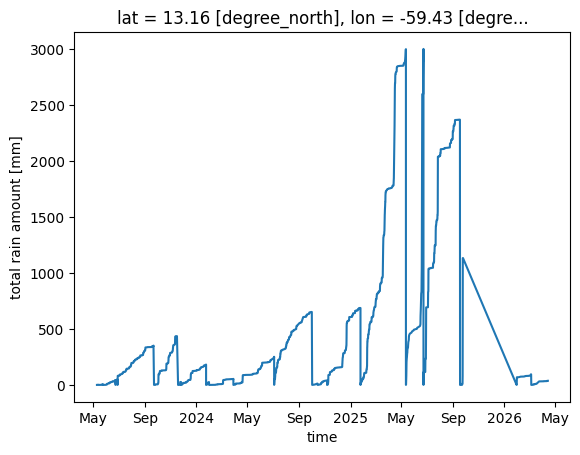

In [7]:
wad['R'].plot()

In [47]:
start_time, end_time = "2026-01-29", datetime.now()

## Total Rain Amount
Why is there that big jump at the beginning of February? The satellite suggests that there was some low clouds around but it does not suggest that significant precipitation should have occurred at this time.

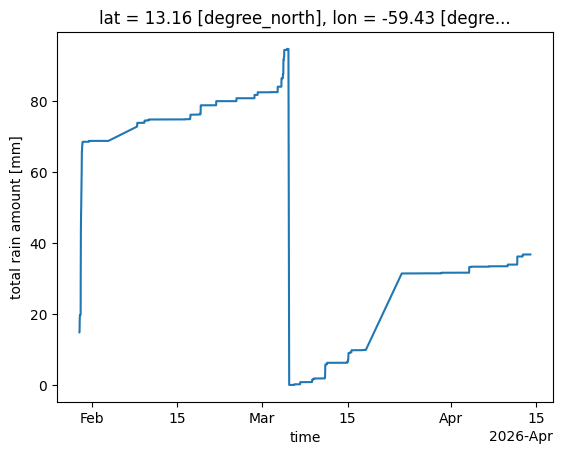

In [46]:
wad['R'].sel(time=slice(start_time, end_time)).plot()

## Rain Intensity
The large jump in precipitation at the beginning of the timeseries is present here in the rainfall intensity as well.

In [ ]:
wad['RIH'].sel(time=slice(start_time, end_time)).plot()

Instead of starting the analysis from January 29th, 2026, it will be done from the 31st.

In [50]:
start_time, end_time = "2026-01-31", datetime.now()

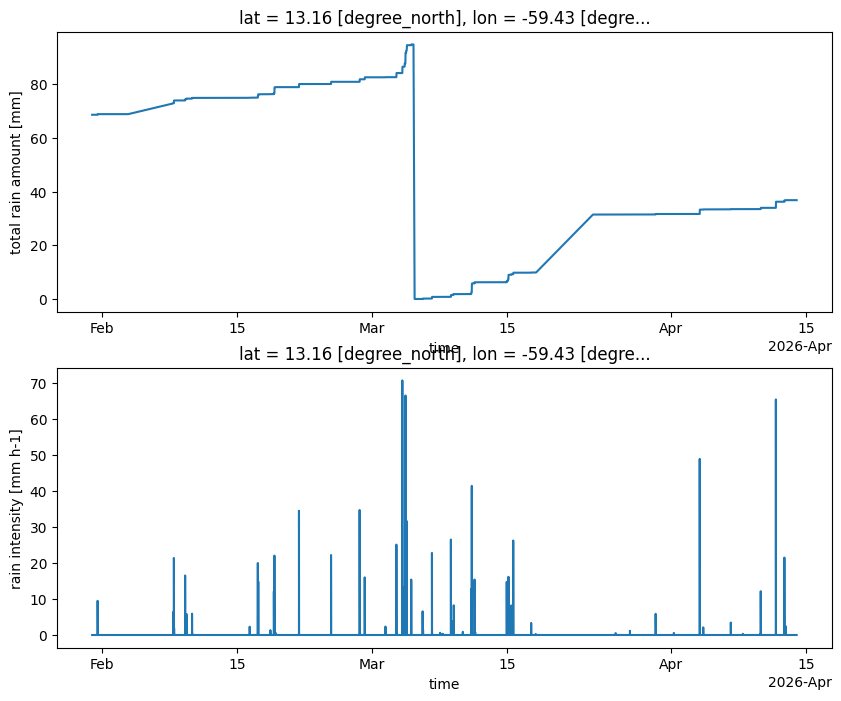

In [51]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

wad['R'].sel(time=slice(start_time, end_time)).plot(ax=ax1)
wad['RIH'].sel(time=slice(start_time, end_time)).plot(ax=ax2)

## Decimal representation of status bits
The SYS variable looks good.

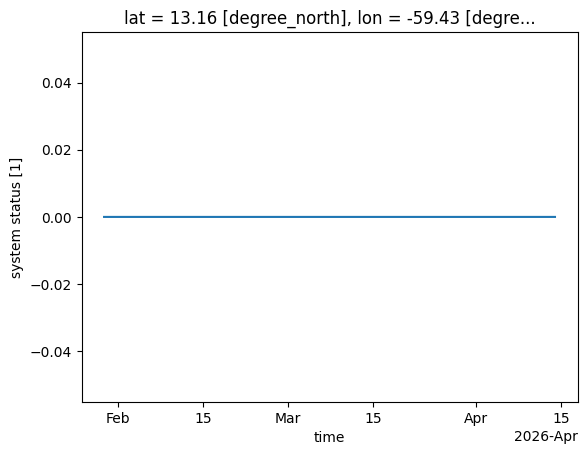

In [ ]:
wad['SYS'].sel(time=slice(start_time, end_time)).plot()

## Ambient Temperature
There are two gaps in the time series for the ambient air temperature. Though it looks fine for now.

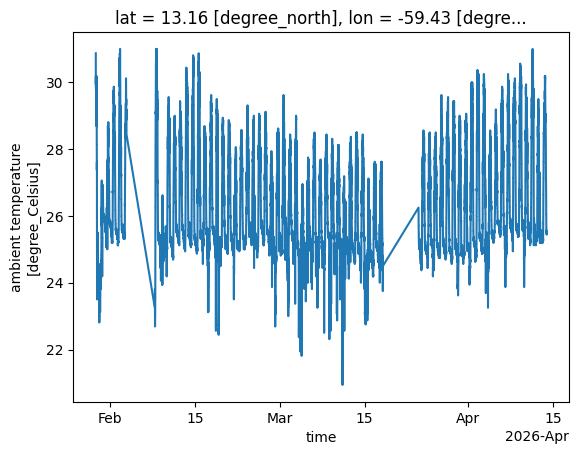

In [25]:
    wad['T'].sel(time=slice(start_time, end_time)).plot()

<>:7: SyntaxWarning: invalid escape sequence '\c'
<>:7: SyntaxWarning: invalid escape sequence '\c'
C:\Users\cpope\AppData\Local\Temp\ipykernel_28308\3179529376.py:7: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel("Temperature / $\circ$C")


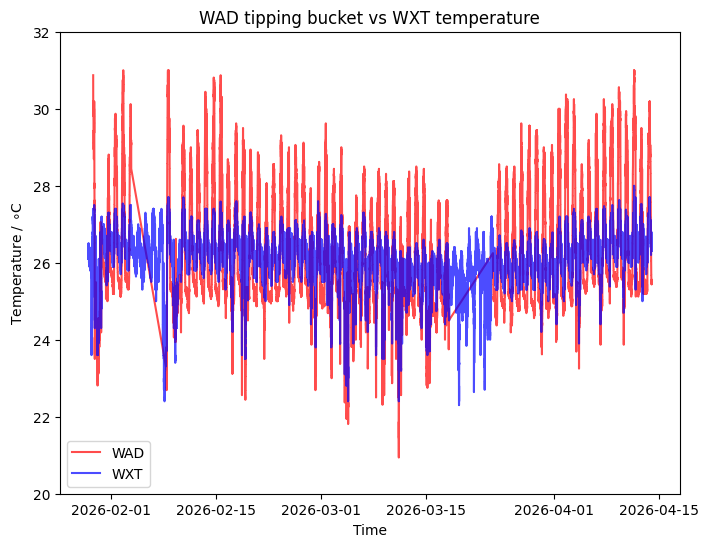

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(T_WAD['time'], T_WAD, color='red', label='WAD', alpha=0.7)
ax.plot(T_WXT['time'], T_WXT, color='blue', alpha=0.7, label='WXT')

ax.set_xlabel("Time")
ax.set_ylabel("Temperature / $\circ$C")
ax.set_title("WAD tipping bucket vs WXT temperature")
ax.set_ylim(20, 32)
ax.legend()

plt.show()